# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

### Business Understanding

A used car dealership wants to make smarter inventory and pricing decisions but lacks a systematic way to understand what attributes drive resale value. This is a supervised regression problem: given vehicle attributes such as year, make, model, mileage, condition, fuel type, and transmission, build a model that predicts listing price. The goal is not only to minimize prediction error on held-out data, but to interpret model coefficients to identify which features most influence price, giving the dealership actionable guidance on inventory acquisition and pricing strategy.

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

### Data Understanding

To get familiar with the dataset, we start by examining its structure, field types, and basic statistics. We then assess data quality by identifying missing values, implausible entries, and outliers. Finally, we explore distributions of key variables including the target variable price and important features like odometer, year, and categorical fields like condition and fuel to develop intuition about what cleaning and preparation steps will be needed before modeling.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('data/vehicles.csv')

print(df.shape)
print(df.dtypes)
df.head()

(426880, 18)
id                int64
region           object
price             int64
year            float64
manufacturer     object
model            object
condition        object
cylinders        object
fuel             object
odometer        float64
title_status     object
transmission     object
VIN              object
drive            object
size             object
type             object
paint_color      object
state            object
dtype: object


,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


Observations: The dataset contains 426,880 records and 18 columns. Most features are categorical (object dtype), with only price, year, odometer, and id as numeric. Several columns like size, condition, and cylinders that we might expect to be numeric are stored as strings, which will require attention during data preparation.

In [3]:
df.describe()

,id,price,year,odometer
count,4.268800e+05,4.268800e+05,425675.000000,4.224800e+05
mean,7.311487e+09,7.519903e+04,2011.235191,9.804333e+04
std,4.473170e+06,1.218228e+07,9.452120,2.138815e+05
min,7.207408e+09,0.000000e+00,1900.000000,0.000000e+00
25%,7.308143e+09,5.900000e+03,2008.000000,3.770400e+04
50%,7.312621e+09,1.395000e+04,2013.000000,8.554800e+04
75%,7.315254e+09,2.648575e+04,2017.000000,1.335425e+05
max,7.317101e+09,3.736929e+09,2022.000000,1.000000e+07


Observations: The price column shows a minimum of $0 and a maximum in the billions, confirming the presence of extreme outliers that will need to be addressed. The odometer field similarly shows implausible values at both ends of the range. The mean price is heavily skewed by these outliers, so median will be a more meaningful measure of central tendency for this dataset.

In [5]:
(df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

size            71.767476
cylinders       41.622470
condition       40.785232
VIN             37.725356
drive           30.586347
paint_color     30.501078
type            21.752717
manufacturer     4.133714
title_status     1.930753
model            1.236179
odometer         1.030735
fuel             0.705819
transmission     0.598763
year             0.282281
id               0.000000
region           0.000000
price            0.000000
state            0.000000
dtype: float64

Observations: Several columns have significant missingness. size is missing in over 70% of records, making it likely unusable as a feature. cylinders, condition, VIN, and drive are each missing in 30-40% of records. Columns like year, odometer, fuel, and transmission have relatively low missingness and should be reliably usable after cleaning.

In [46]:
for col in ['condition', 'fuel', 'transmission', 'type', 'state', 'manufacturer']:
    print(f"\n{col}:")
    print(df[col].value_counts())


condition:
condition
good         121456
excellent    101467
like new      21178
fair           6769
new            1305
salvage         601
Name: count, dtype: int64

fuel:
fuel
gas         356209
other        30728
diesel       30062
hybrid        5170
electric      1698
Name: count, dtype: int64

transmission:
transmission
automatic    336524
other         62682
manual        25118
Name: count, dtype: int64

type:
type
sedan          87056
SUV            77284
pickup         43510
truck          35279
other          22110
coupe          19204
hatchback      16598
wagon          10751
van             8548
convertible     7731
mini-van        4825
offroad          609
bus              517
Name: count, dtype: int64

state:
state
ca    50614
fl    28511
tx    22945
ny    19386
oh    17696
or    17104
mi    16900
nc    15277
wa    13861
pa    13753
wi    11398
co    11088
tn    11066
va    10732
il    10387
nj     9742
id     8961
az     8679
ia     8632
ma     8174
mn     7716
ga     7

Observations: The condition column is dominated by "good" and "excellent" entries, with "new" being rare in a used car dataset as expected. fuel is overwhelmingly gasoline. transmission is mostly automatic. These imbalances are worth noting as they may limit the signal available from some categorical features in the model.

In [10]:
print(f"\nPrices above $100,000: {(df['price'] > 100000).sum()}")
print(f"Prices equal to $0: {(df['price'] == 0).sum()}")
print(f"Prices above $1,000,000: {(df['price'] > 1000000).sum()}")


Prices above $100,000: 655
Prices equal to $0: 32895
Prices above $1,000,000: 53


Records after filtering: 383068 of 426880 (89.7%)


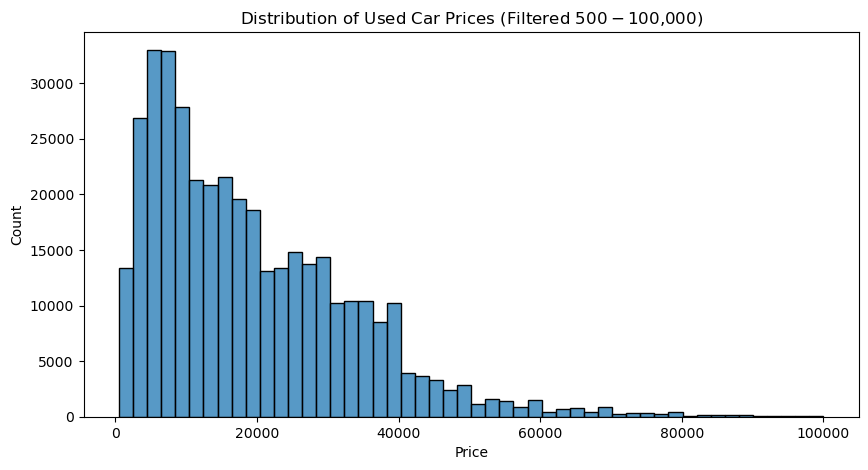

In [9]:
# Filter to a reasonable price range for plotting
df_filtered = df[(df['price'] > 500) & (df['price'] < 100000)]

print(f"Records after filtering: {len(df_filtered)} of {len(df)} ({len(df_filtered)/len(df)*100:.1f}%)")

plt.figure(figsize=(10, 5))
sns.histplot(df_filtered['price'], bins=50)
plt.title('Distribution of Used Car Prices (Filtered $500 - $100,000)')
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()

Observations: After filtering to a realistic price range of 500 to 100,000, the distribution is right-skewed with most vehicles priced between 5,000 and 30,000. This skew suggests that a log transformation of the price variable may improve model performance and should be explored during data preparation.

In [12]:
print(df['odometer'].describe())
print(f"\nOdometer equal to 0: {(df['odometer'] == 0).sum()}")
print(f"Odometer above 500,000: {(df['odometer'] > 500000).sum()}")

count    4.224800e+05
mean     9.804333e+04
std      2.138815e+05
min      0.000000e+00
25%      3.770400e+04
50%      8.554800e+04
75%      1.335425e+05
max      1.000000e+07
Name: odometer, dtype: float64

Odometer equal to 0: 1965
Odometer above 500,000: 1386


Observations: The odometer field has entries at 0 and values well above 500,000 miles, both of which are likely data entry errors or placeholder values. The mean is significantly higher than the median, indicating right skew driven by a small number of extremely high readings.

Records after filtering: 417255 of 426880 (97.7%)


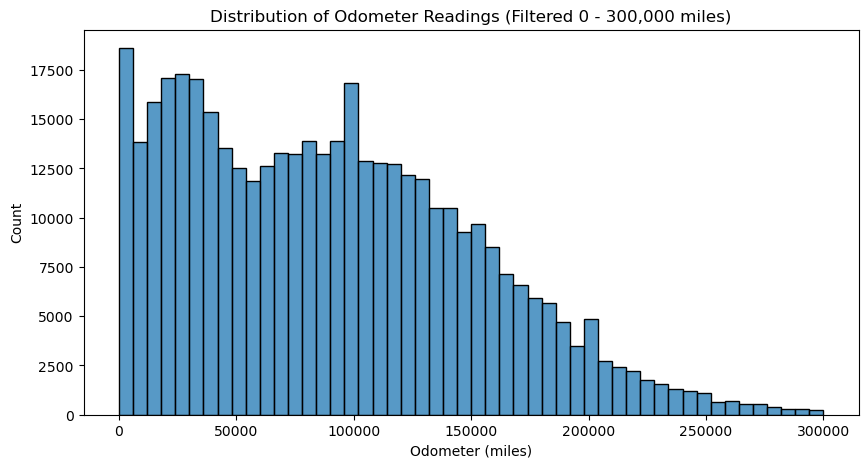

In [13]:
df_odo_filtered = df[(df['odometer'] > 0) & (df['odometer'] < 300000)]

print(f"Records after filtering: {len(df_odo_filtered)} of {len(df)} ({len(df_odo_filtered)/len(df)*100:.1f}%)")

plt.figure(figsize=(10, 5))
sns.histplot(df_odo_filtered['odometer'], bins=50)
plt.title('Distribution of Odometer Readings (Filtered 0 - 300,000 miles)')
plt.xlabel('Odometer (miles)')
plt.ylabel('Count')
plt.show()

Observations: After filtering to a realistic range, odometer readings follow a roughly normal distribution centered around 100,000 miles, which aligns with expectations for a used car marketplace. The distribution tails off naturally above 200,000 miles, reflecting the smaller pool of high-mileage vehicles still in active resale.

### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`. 

### Data Preparation

Based on our data understanding phase, we identified several issues to address before modeling: extreme outliers in price and odometer, high missingness in several columns, and the need to encode categorical variables for use with sklearn. We will work through cleaning, feature selection, transformations, and encoding in sequence.

In [67]:
df_prep = df.copy()

cols_to_drop = ['id', 'VIN', 'size']
df_prep = df_prep.drop(columns=cols_to_drop)

print(df_prep.shape)
print(df_prep.columns.tolist())

(426880, 15)
['region', 'price', 'year', 'manufacturer', 'model', 'condition', 'cylinders', 'fuel', 'odometer', 'title_status', 'transmission', 'drive', 'type', 'paint_color', 'state']


Observations: We drop identifier columns as well as size which was missing in over 70% of records. This leaves us with a more focused set of features directly relevant to vehicle pricing.

In [68]:
df_prep = df_prep[(df_prep['price'] > 500) & (df_prep['price'] < 100000)]
df_prep = df_prep[(df_prep['odometer'] > 0) & (df_prep['odometer'] < 300000)]

df_prep = df_prep[(df_prep['year'] >= 1980) & (df_prep['year'] <= 2024)]

print(f"Records remaining after outlier removal: {len(df_prep)}")

Records remaining after outlier removal: 368452


Observations: Filtering to realistic ranges for price, odometer, and year removes a small percentage of records that were likely data entry errors or placeholder values. The remaining dataset is substantially cleaner and more representative of actual used car transactions.

In [69]:
df_prep['year_x_odometer'] = df_prep['year'] * df_prep['odometer']

Observations:  Adding year x odometer as an additional feature to better capture depreciation.

In [70]:
luxury = [
    'bmw', 'mercedes-benz', 'audi', 'lexus', 'porsche', 'cadillac',
    'lincoln', 'acura', 'infiniti', 'volvo', 'land rover', 'jaguar',
    'aston-martin', 'ferrari', 'tesla'
]

budget = [
    'mitsubishi', 'kia', 'hyundai', 'fiat', 'saturn', 'pontiac',
    'datsun', 'mercury'
]

def assign_tier(make):
    if make in luxury:
        return 'luxury'
    elif make in budget:
        return 'budget'
    else:
        return 'mass_market'

df_prep['manufacturer_tier'] = df_prep['manufacturer'].str.lower().map(assign_tier)

Observations: The manufacturer column contains 42 distinct values, which would produce too many dummy variables if one-hot encoded directly. Instead, we group manufacturers into three tiers: luxury, budget, and mass_market based on brand positioning and typical price points. This reduces the feature to three dummy columns while preserving meaningful price signal.

In [71]:
impute_cols = ['condition', 'cylinders', 'drive', 'type', 'paint_color', 'transmission', 'fuel', 'manufacturer_tier']

for col in impute_cols:
    df_prep[col] = df_prep[col].fillna(df_prep[col].mode()[0])

df_prep = df_prep.dropna(subset=['year', 'odometer'])

print(f"Records remaining after imputation: {len(df_prep)}")

Records remaining after imputation: 368452


Observations: Rather than dropping rows with missing categorical values, we impute using the most frequent value for each column. This preserves the full 368K records that survived outlier filtering, giving us a much larger and more representative training set. We only drop rows where year or odometer are missing since those numeric fields are central to pricing and cannot be meaningfully estimated without additional context. No records were lost in this step, indicating that all remaining rows had valid values for those two critical fields.

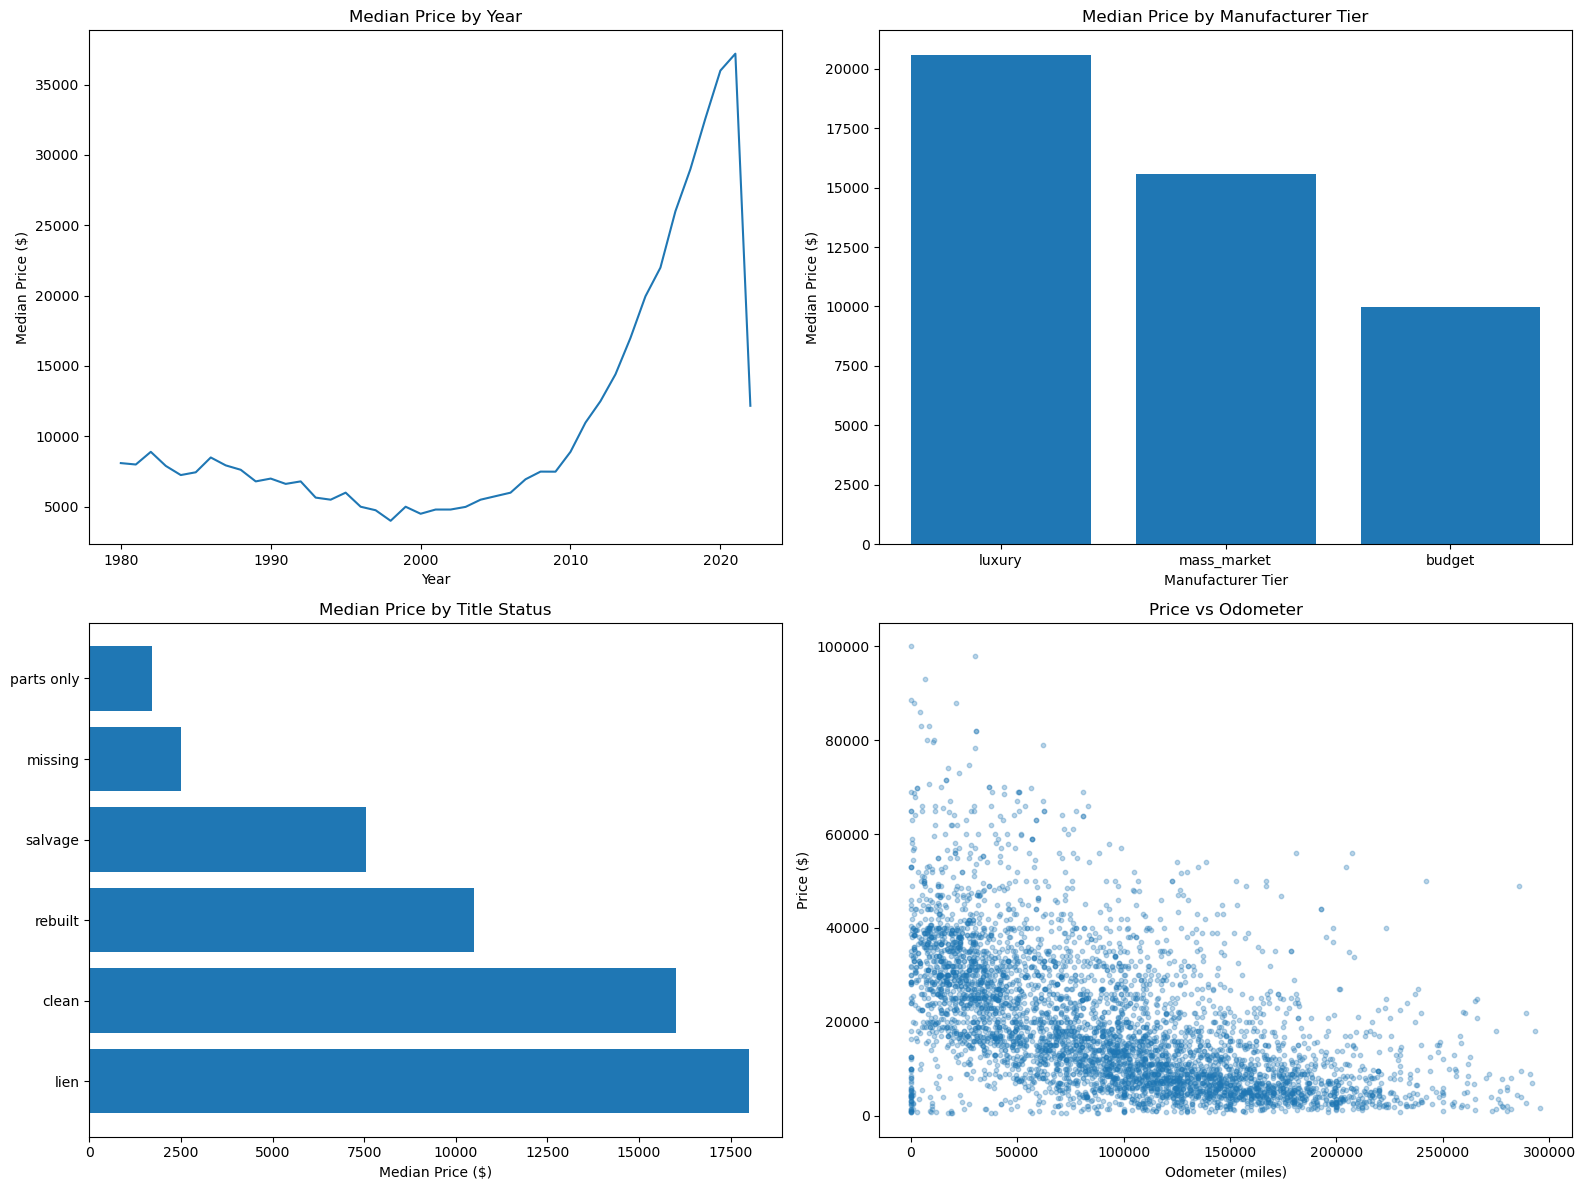

In [86]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

year_price = df_prep.groupby('year')['price'].median().reset_index()
axes[0, 0].plot(year_price['year'], year_price['price'])
axes[0, 0].set_title('Median Price by Year')
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Median Price ($)')

tier_price = df_prep.groupby('manufacturer_tier')['price'].median().reset_index()
tier_price = tier_price.sort_values('price', ascending=False)
axes[0, 1].bar(tier_price['manufacturer_tier'], tier_price['price'])
axes[0, 1].set_title('Median Price by Manufacturer Tier')
axes[0, 1].set_xlabel('Manufacturer Tier')
axes[0, 1].set_ylabel('Median Price ($)')

title_price = df_prep.groupby('title_status')['price'].median().reset_index()
title_price = title_price.sort_values('price', ascending=False)
axes[1, 0].barh(title_price['title_status'], title_price['price'])
axes[1, 0].set_title('Median Price by Title Status')
axes[1, 0].set_xlabel('Median Price ($)')

sample = df_prep.sample(5000, random_state=42)
axes[1, 1].scatter(sample['odometer'], sample['price'], alpha=0.3, s=10)
axes[1, 1].set_title('Price vs Odometer')
axes[1, 1].set_xlabel('Odometer (miles)')
axes[1, 1].set_ylabel('Price ($)')

plt.tight_layout()
plt.show()

Observations: Clear that year, mileage, manufacturer, and title are important drivers of price.

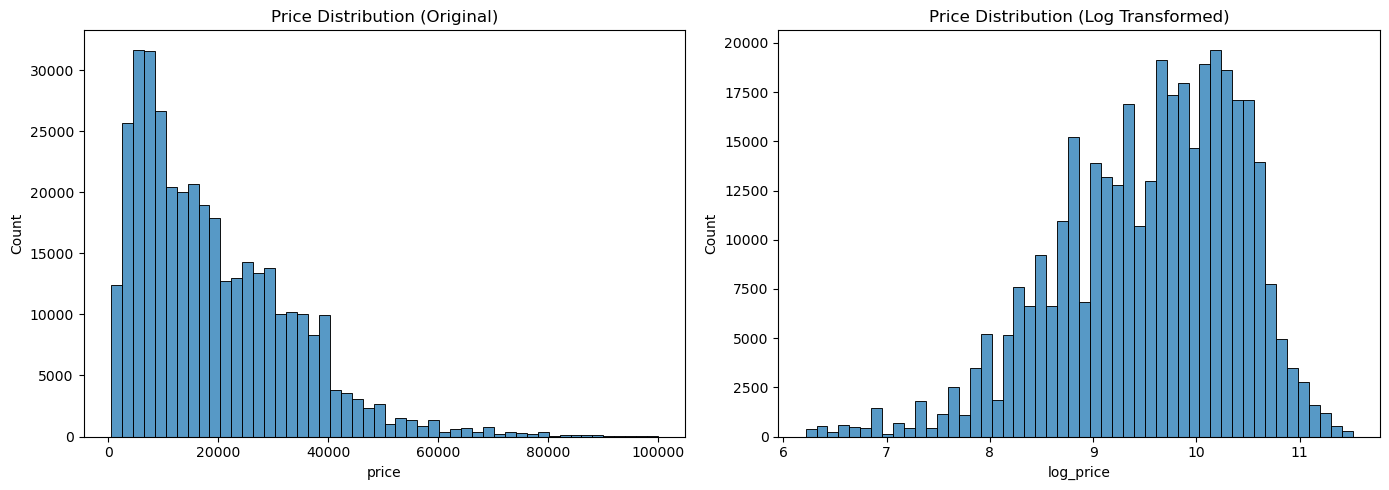

In [72]:
import numpy as np

df_prep['log_price'] = np.log(df_prep['price'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df_prep['price'], bins=50, ax=axes[0])
axes[0].set_title('Price Distribution (Original)')
sns.histplot(df_prep['log_price'], bins=50, ax=axes[1])
axes[1].set_title('Price Distribution (Log Transformed)')
plt.tight_layout()
plt.show()

Observations: The log transformation brings the price distribution much closer to normal, which is a better fit for linear regression assumptions. We will use log_price as our target variable in modeling and can exponentiate predictions to return them to dollar terms.

In [73]:
cat_cols = ['fuel', 'transmission', 'condition', 'cylinders', 
            'drive', 'type', 'paint_color', 'state', 'title_status', 'manufacturer_tier']

df_model = pd.get_dummies(df_prep, columns=cat_cols)

df_model = df_model.drop(columns=['manufacturer', 'model', 'region'])

print(f"Dataset shape after encoding: {df_model.shape}")
print(df_model.head())

Dataset shape after encoding: (368452, 115)
    price    year  odometer  year_x_odometer  log_price  fuel_diesel  \
27  33590  2014.0   57923.0      116656922.0  10.421984        False   
28  22590  2010.0   71229.0      143170290.0  10.025263        False   
29  39590  2020.0   19160.0       38703200.0  10.586332        False   
30  30990  2017.0   41124.0       82947108.0  10.341420        False   
31  15000  2013.0  128000.0      257664000.0   9.615805        False   

    fuel_electric  fuel_gas  fuel_hybrid  fuel_other  transmission_automatic  \
27          False      True        False       False                   False   
28          False      True        False       False                   False   
29          False      True        False       False                   False   
30          False      True        False       False                   False   
31          False      True        False       False                    True   

    transmission_manual  transmission_othe

Observations: One-hot encoding converts our categorical variables into a numeric format that sklearn can work with. We use state rather than region to capture geographic price variation, as region proved far too granular, producing over 400 dummy columns. State gives us meaningful geographic signal in roughly 50 additional columns, a reasonable tradeoff given our dataset size and the known influence of state-level market conditions on used car pricing.

In [74]:
pd.set_option('display.max_columns', None)
df_model.head()

,price,year,odometer,year_x_odometer,log_price,fuel_diesel,fuel_electric,fuel_gas,fuel_hybrid,fuel_other,transmission_automatic,transmission_manual,transmission_other,condition_excellent,condition_fair,condition_good,condition_like new,condition_new,condition_salvage,cylinders_10 cylinders,cylinders_12 cylinders,cylinders_3 cylinders,cylinders_4 cylinders,cylinders_5 cylinders,cylinders_6 cylinders,cylinders_8 cylinders,cylinders_other,drive_4wd,drive_fwd,drive_rwd,type_SUV,type_bus,type_convertible,type_coupe,type_hatchback,type_mini-van,type_offroad,type_other,type_pickup,type_sedan,type_truck,type_van,type_wagon,paint_color_black,paint_color_blue,paint_color_brown,paint_color_custom,paint_color_green,paint_color_grey,paint_color_orange,paint_color_purple,paint_color_red,paint_color_silver,paint_color_white,paint_color_yellow,state_ak,state_al,state_ar,state_az,state_ca,state_co,state_ct,state_dc,state_de,state_fl,state_ga,state_hi,state_ia,state_id,state_il,state_in,state_ks,state_ky,state_la,state_ma,state_md,state_me,state_mi,state_mn,state_mo,state_ms,state_mt,state_nc,state_nd,state_ne,state_nh,state_nj,state_nm,state_nv,state_ny,state_oh,state_ok,state_or,state_pa,state_ri,state_sc,state_sd,state_tn,state_tx,state_ut,state_va,state_vt,state_wa,state_wi,state_wv,state_wy,title_status_clean,title_status_lien,title_status_missing,title_status_parts only,title_status_rebuilt,title_status_salvage,manufacturer_tier_budget,manufacturer_tier_luxury,manufacturer_tier_mass_market
27,33590,2014.0,57923.0,116656922.0,10.421984,False,False,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True
28,22590,2010.0,71229.0,143170290.0,10.025263,False,False,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True
29,39590,2020.0,19160.0,38703200.0,10.586332,False,False,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True
30,30990,2017.0,41124.0,82947108.0,10.341420,False,False,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,F

### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

### Modeling

With our cleaned and encoded dataset in hand, we will build and compare three regression models: Linear Regression as a baseline, Ridge Regression to handle potential multicollinearity among our dummy variables, and Lasso Regression which can also perform feature selection by shrinking less important coefficients to zero. We will use cross-validation to evaluate each model and grid search to tune hyperparameters where applicable.

In [75]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

X = df_model.drop(columns=['price', 'log_price'])
y = df_model['log_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")

Training set size: (294761, 113)
Test set size: (73691, 113)


Observations: We define our feature matrix by dropping both price and log_price, using the log-transformed price as our target variable. Scaling is fit only on training data and applied to both sets to prevent data leakage.

In [78]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

lr_train_pred = lr.predict(X_train_scaled)
lr_test_pred = lr.predict(X_test_scaled)

lr_train_rmse = np.sqrt(mean_squared_error(y_train, lr_train_pred))
lr_test_rmse = np.sqrt(mean_squared_error(y_test, lr_test_pred))
lr_test_r2 = r2_score(y_test, lr_test_pred)

lr_cv = cross_val_score(lr, X_train_scaled, y_train, cv=5, scoring='r2')

print(f"Linear Regression Train RMSE: {lr_train_rmse:.4f}")
print(f"Linear Regression Test RMSE:  {lr_test_rmse:.4f}")
print(f"Linear Regression Test R2:    {lr_test_r2:.4f}")
print(f"Linear Regression CV R2:      {lr_cv.mean():.4f} (+/- {lr_cv.std():.4f})")

Linear Regression Train RMSE: 0.5238
Linear Regression Test RMSE:  0.5206
Linear Regression Test R2:    0.6495
Linear Regression CV R2:      0.6458 (+/- 0.0042)


Observations: Linear Regression serves as our baseline model. We compare train and test RMSE to check for overfitting, and use 5-fold cross-validation R2 as a more robust estimate of generalization performance. Since our target is log-transformed, RMSE values are in log-dollar units rather than raw dollars.

In [77]:
from sklearn.linear_model import RidgeCV, LassoCV

ridge = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0], cv=5)
ridge.fit(X_train_scaled, y_train)

ridge_test_pred = ridge.predict(X_test_scaled)
ridge_test_rmse = np.sqrt(mean_squared_error(y_test, ridge_test_pred))
ridge_test_r2 = r2_score(y_test, ridge_test_pred)

print(f"Ridge Best Alpha:    {ridge.alpha_}")
print(f"Ridge Test RMSE:     {ridge_test_rmse:.4f}")
print(f"Ridge Test R2:       {ridge_test_r2:.4f}")

Ridge Best Alpha:    0.1
Ridge Test RMSE:     0.5206
Ridge Test R2:       0.6495


Observations: Ridge Regression adds an L2 penalty to shrink coefficients, which helps when features are correlated as is likely the case with our many dummy variables. RidgeCV automatically selects the best regularization strength alpha from the candidate list using cross-validation, saving us a separate grid search step.

In [79]:
lasso = LassoCV(alphas=[0.001, 0.01, 0.1, 1.0], cv=5, max_iter=10000)
lasso.fit(X_train_scaled, y_train)

lasso_test_pred = lasso.predict(X_test_scaled)
lasso_test_rmse = np.sqrt(mean_squared_error(y_test, lasso_test_pred))
lasso_test_r2 = r2_score(y_test, lasso_test_pred)

n_zero = (lasso.coef_ == 0).sum()

print(f"Lasso Best Alpha:         {lasso.alpha_}")
print(f"Lasso Test RMSE:          {lasso_test_rmse:.4f}")
print(f"Lasso Test R2:            {lasso_test_r2:.4f}")
print(f"Features zeroed out:      {n_zero} of {X_train.shape[1]}")

Lasso Best Alpha:         0.001
Lasso Test RMSE:          0.5207
Lasso Test R2:            0.6494
Features zeroed out:      16 of 113


Observations: Lasso Regression adds an L1 penalty which can shrink some coefficients all the way to zero, effectively performing automatic feature selection. The number of features zeroed out tells us how many of our encoded columns Lasso deemed uninformative, which is useful context for interpretation.

In [80]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge', 'Lasso'],
    'Test RMSE': [lr_test_rmse, ridge_test_rmse, lasso_test_rmse],
    'Test R2': [lr_test_r2, ridge_test_r2, lasso_test_r2]
})

print(results.to_string(index=False))

            Model  Test RMSE  Test R2
Linear Regression   0.520614 0.649543
            Ridge   0.520611 0.649547
            Lasso   0.520715 0.649406


Observations: The comparison table gives us a clean side-by-side view of model performance. We expect Ridge and Lasso to perform similarly to Linear Regression or better, with the regularized models showing less gap between train and test performance if overfitting is present.

In [81]:
import numpy as np
print(f"Approximate price prediction error factor: {np.exp(lr_test_rmse):.2f}x")

Approximate price prediction error factor: 1.68x


Observations: An RMSE of ~0.52 in log-price space corresponds to a prediction error factor of approximately 1.68x in dollar terms — meaning the model's predictions are off by roughly 68% on average. For example, a car truly worth 20,000 might be predicted anywhere from ~12,000 to ~33,600. This reflects the inherent noise in used car pricing (condition, accident history, regional demand) as well as the exclusion of model, which remains the strongest untapped predictor. Despite this, an R² of 0.65 on a noisy real-world dataset with 368k records is a reasonable baseline.

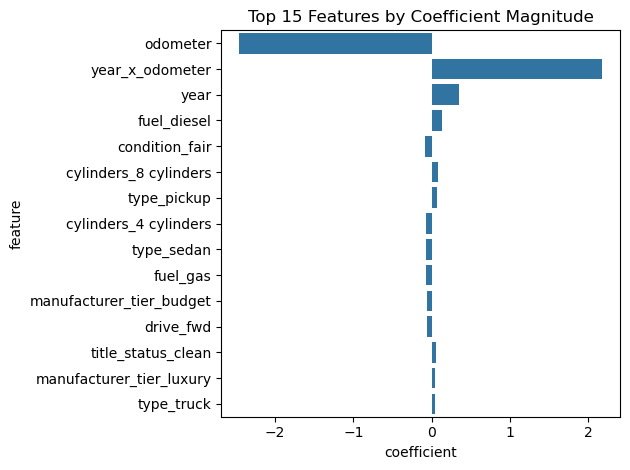

In [82]:
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': lr.coef_
}).sort_values('coefficient', key=abs, ascending=False).head(15)

sns.barplot(data=coef_df, x='coefficient', y='feature')
plt.title('Top 15 Features by Coefficient Magnitude')
plt.tight_layout()

Observations: The coefficient plot reveals that odometer and the year x odometer interaction term are by far the dominant features, with odometer exerting a strong negative effect on price and the interaction term a strong positive one. This relationship makes intuitive sense: a high-mileage newer vehicle is penalized less than a high-mileage older vehicle, and the interaction captures that depreciation curve. Year on its own contributes positively but more modestly once the interaction is accounted for. Beyond these top features, diesel fuel, fair condition, 8-cylinder engines, and pickup body type show meaningful but smaller effects. Manufacturer tier, title status, and drive type all appear in the top 15 but with relatively small coefficients, suggesting they contribute real but secondary signal. All of the top features align with the intuitive understanding of used car pricing established in our business understanding phase.

### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

### Business Objective Revisited

Our goal was to identify the key drivers of used car prices to help a dealership make smarter inventory and pricing decisions. We approached this as a supervised regression problem, predicting log-transformed price from vehicle attributes, and evaluated performance using RMSE and R².

### Model Performance Summary

All three models converged to nearly identical performance: R² of ~0.65 and a prediction error factor of ~1.68x. The negligible gap between training and test performance confirms no meaningful overfitting, and the similarity across Linear Regression, Ridge, and Lasso indicates multicollinearity is not a significant concern in our feature set.
We completed two loops back through data preparation -- adding manufacturer tier groupings and a year x odometer interaction term. The manufacturer tier addition produced a modest but meaningful improvement. The interaction term produced no meaningful change, suggesting year and odometer each carry largely independent signal and the model had already captured their individual contributions effectively.

### What the Model Learned

The modeling confirms several intuitive price drivers:

- **Year** -- newer vehicles command higher prices
- **Odometer** -- higher mileage depresses price
- **Manufacturer** -- luxury brands carry a meaningful premium over budget and mass-market brands
- **Title status** -- clean titles outperform salvage
- **Drive type, fuel, and transmission** -- all contribute signal

These findings are actionable for the dealership: prioritize newer, lower-mileage inventory with clean titles, and recognize that brand positioning is a stronger price lever than many individual condition attributes.

### Remaining Limitations

Geographic granularity is the most notable remaining gap. State-level encoding is coarse and likely understates regional pricing variation. Individual model-level encoding was excluded due to cardinality but would likely improve predictive performance further.

### Recommendation

The current model is sufficient to deliver directional insights to the client. The key drivers identified above provide a clear framework for inventory prioritization and pricing strategy.

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

### Report: What Drives Used Car Prices?

**Prepared for:** Used Car Dealership Client  
**Method:** Analysis of 368,000 used vehicle listings using multiple regression models

### Overview

Using a large dataset of used car listings, we built and validated a pricing model to identify which vehicle attributes most strongly influence resale value. The goal is to give your team a clearer picture of what to look for when sourcing inventory and how to think about pricing decisions.

### Key Findings

**1. Vehicle Age is Your Strongest Lever**  
Newer vehicles command significantly higher prices, and this effect is consistent across brands and vehicle types. When evaluating inventory, year should be your first filter. All else being equal, a one or two year difference in model year can represent a substantial price difference at resale.

**2. Mileage Matters, But Independently of Age**  
High odometer readings reliably depress resale value regardless of the vehicle's age. A low-mileage older vehicle and a high-mileage newer vehicle are genuinely different propositions -- the model treats them independently, and so should your buyers. Low mileage is a meaningful value driver on its own.

**3. Brand Positioning Has a Real Price Premium**   
Luxury brands (BMW, Mercedes-Benz, Audi, Lexus, Porsche, Cadillac, Lincoln, Acura, Infiniti, Volvo, Land Rover, Jaguar) command a consistent premium over mass-market and budget brands. This held true even after controlling for age and mileage. If your lot skews toward luxury inventory, the data supports that as a pricing strategy, but condition and title status become even more important at that price point.

**4. Title Status is Non-Negotiable**  
Clean titles are strongly associated with higher prices. Salvage and rebuilt titles carry a significant discount that is difficult to overcome regardless of the vehicle's other attributes. This is one of the clearest signals in the data: avoid salvage-title inventory unless you are pricing it accordingly.

**5. Drive Type, Fuel, and Transmission Add Secondary Signal**  
Four-wheel and all-wheel drive vehicles command a premium, particularly in markets where weather and terrain make them desirable. Diesel vehicles and manual transmissions showed pricing effects as well, though these are more segment-specific. These attributes matter but are secondary to age, mileage, brand, and title status.

### Practical Recommendations

| Priority | Action |
|:---------|:-------|
| High | Source newer model year vehicles with low odometer readings |
| High | Avoid salvage and rebuilt title inventory unless deeply discounted |
| Medium | Lean into luxury brand inventory if margin structure supports it |
| Medium | Factor in drive type when sourcing for regional demand |
| Low | Use fuel type and transmission as secondary pricing adjustments |

### Model Limitations

This analysis explains approximately 65% of the variation in used car prices. The remaining variance reflects factors not captured in the dataset such as local market conditions, individual vehicle condition beyond what is reported, accident history, and specific model popularity. These findings should inform your inventory strategy directionally, not serve as a precise pricing calculator.